<a href="https://colab.research.google.com/github/jaimeisaac2020/Python-analsisis-basicos/blob/mi-github/pronosticos_GA_julio_2025_tesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
pip install pandas numpy tensorflow scikit-learn

In [7]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import os

# --- 1. Carga de Datos desde el archivo CSV ---
# Nombre del archivo que debe estar en el mismo directorio que el script.
file_name = 'precios_cierre_2025_google_amazon.csv'

# Verificar si el archivo existe antes de continuar
if not os.path.exists(file_name):
    print(f"Error: El archivo '{file_name}' no se encontró.")
    print("Por favor, asegúrate de que el archivo CSV esté en la misma carpeta que el script.")
else:
    # Cargar los datos desde el archivo CSV
    df = pd.read_csv(file_name)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

    # Función para crear secuencias de datos para la LSTM
    def create_sequences(data, look_back=1):
        X, y = [], []
        for i in range(len(data) - look_back):
            X.append(data[i:(i + look_back), 0])
            y.append(data[i + look_back, 0])
        return np.array(X), np.array(y)

    # Función principal para entrenar y pronosticar
    def train_and_forecast(data, look_back, forecast_days):
        """
        Entrena un modelo LSTM y pronostica los precios futuros.

        :param data: Serie de precios históricos (una sola columna).
        :param look_back: Número de días pasados a usar para la predicción.
        :param forecast_days: Número de días a pronosticar en el futuro.
        :return: Array con los precios pronosticados.
        """
        # Escalar los datos
        scaler = MinMaxScaler(feature_range=(0, 1))
        scaled_data = scaler.fit_transform(data.values.reshape(-1, 1))

        # Crear secuencias de entrenamiento
        X_train, y_train = create_sequences(scaled_data, look_back)
        X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

        # --- Construcción y Entrenamiento del Modelo LSTM ---
        model = Sequential([
            LSTM(50, return_sequences=True, input_shape=(look_back, 1)),
            Dropout(0.2),
            LSTM(50, return_sequences=False),
            Dropout(0.2),
            Dense(25),
            Dense(1)
        ])

        model.compile(optimizer='adam', loss='mean_squared_error')

        # El entrenamiento se hace con pocas 'epochs' para que sea rápido.
        # Para mayor precisión, se podrían aumentar.
        model.fit(X_train, y_train, batch_size=1, epochs=20, verbose=0)

        # --- Generación de Pronósticos ---
        last_sequence = scaled_data[-look_back:]
        current_batch = last_sequence.reshape((1, look_back, 1))
        future_predictions = []

        for i in range(forecast_days):
            current_pred = model.predict(current_batch, verbose=0)[0]
            future_predictions.append(current_pred)
            current_batch = np.append(current_batch[:, 1:, :], [[current_pred]], axis=1)

        # Invertir la escala de las predicciones
        forecasted_prices = scaler.inverse_transform(future_predictions)

        return forecasted_prices.flatten()

    # --- Ejecución del Pronóstico para cada Acción ---

    # Definir parámetros
    LOOK_BACK = 60
    LAST_DATE = df.index[-1]

    # Calcular los días a pronosticar (días hábiles hasta fin de julio 2025)
    forecast_dates = pd.bdate_range(start=LAST_DATE + pd.Timedelta(days=1), end='2025-07-31')
    FORECAST_DAYS = len(forecast_dates)

    print("Iniciando el pronóstico...")
    print(f"Leyendo datos desde: {file_name}")
    print(f"Datos históricos hasta: {LAST_DATE.date()}")
    print(f"Período a pronosticar: {forecast_dates[0].date()} a {forecast_dates[-1].date()} ({FORECAST_DAYS} días hábiles)")
    print("-" * 50)

    # Pronóstico para Amazon (AMZN)
    print("Entrenando modelo y pronosticando para Amazon (AMZN)...")
    amzn_data = df[['AMZN_Close']]
    amzn_forecast = train_and_forecast(amzn_data, LOOK_BACK, FORECAST_DAYS)
    print("Pronóstico para AMZN completado.")
    print("-" * 50)

    # Pronóstico para Google (GOOGL)
    print("Entrenando modelo y pronosticando para Google (GOOGL)...")
    googl_data = df[['GOOGL_Close']]
    googl_forecast = train_and_forecast(googl_data, LOOK_BACK, FORECAST_DAYS)
    print("Pronóstico para GOOGL completado.")
    print("-" * 50)

    # --- Presentación de Resultados ---

    # Crear un DataFrame con los resultados
    forecast_df = pd.DataFrame({
        'Date': forecast_dates,
        'AMZN_Forecast': amzn_forecast,
        'GOOGL_Forecast': googl_forecast
    })

    # Formatear la salida para una mejor lectura
    forecast_df['AMZN_Forecast'] = forecast_df['AMZN_Forecast'].map('${:,.2f}'.format)
    forecast_df['GOOGL_Forecast'] = forecast_df['GOOGL_Forecast'].map('${:,.2f}'.format)
    forecast_df.set_index('Date', inplace=True)

    print("\n*** PRONÓSTICO DE PRECIOS DE CIERRE (JUNIO - JULIO 2025) ***\n")
    print(forecast_df)

Iniciando el pronóstico...
Leyendo datos desde: precios_cierre_2025_google_amazon.csv
Datos históricos hasta: 2025-06-27
Período a pronosticar: 2025-06-30 a 2025-07-31 (24 días hábiles)
--------------------------------------------------
Entrenando modelo y pronosticando para Amazon (AMZN)...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Pronóstico para AMZN completado.
--------------------------------------------------
Entrenando modelo y pronosticando para Google (GOOGL)...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Pronóstico para GOOGL completado.
--------------------------------------------------

*** PRONÓSTICO DE PRECIOS DE CIERRE (JUNIO - JULIO 2025) ***

           AMZN_Forecast GOOGL_Forecast
Date                                   
2025-06-30       $207.67        $169.46
2025-07-01       $207.26        $169.36
2025-07-02       $206.18        $168.96
2025-07-03       $204.81        $168.43
2025-07-04       $203.30        $167.85
2025-07-07       $201.73        $167.25
2025-07-08       $200.14        $166.65
2025-07-09       $198.53        $166.05
2025-07-10       $196.93        $165.46
2025-07-11       $195.34        $164.88
2025-07-14       $193.77        $164.31
2025-07-15       $192.23        $163.75
2025-07-16       $190.73        $163.21
2025-07-17       $189.27        $162.68
2025-07-18       $187.88        $162.18
2025-07-21       $186.56        $161.70
2025-07-22       $185.32        $161.24
2025-07-23       $184.16        $160.82
2025-07-24       $183.09        $160.42
2025-07-25  

Iniciando el pronóstico...
--------------------------------------------------
Entrenando modelo y pronosticando para Amazon (AMZN)...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Entrenando modelo y pronosticando para Google (GOOGL)...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Pronósticos completados.
--------------------------------------------------
Generando gráficas...

*** PRONÓSTICO DE PRECIOS DE CIERRE (JUNIO - JULIO 2025) ***

           AMZN_Forecast GOOGL_Forecast
Date                                   
2025-06-30       $212.99        $170.41
2025-07-01       $213.14        $170.42
2025-07-02       $212.73        $170.11
2025-07-03       $212.12        $169.69
2025-07-04       $211.43        $169.23
2025-07-07       $210.71        $168.78
2025-07-08       $209.97        $168.32
2025-07-09       $209.19        $167.89
2025-07-10       $208.38        $167.46
2025-07-11       $207.54        $167.06
2025-07-14       $206.66        $166.67
2025-07-15       $205.72        $166.31
2025-07-16       $204.74        $165.96
2025-07-17       $203.71        $165.64
2025-07-18       $202.63        $165.34
2025-07-21       $201.50        $165.06
2025-07-22       $200.33        $164.80
2025-07-23       $199.12        $164.57
2025-07-24       $197.87        $164.36

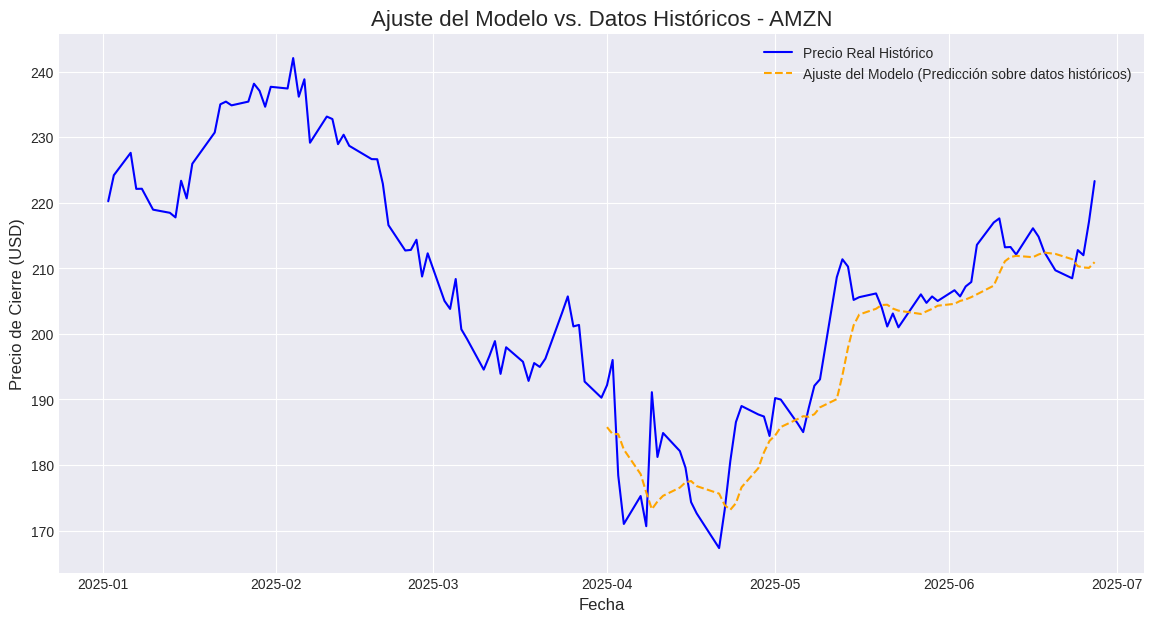

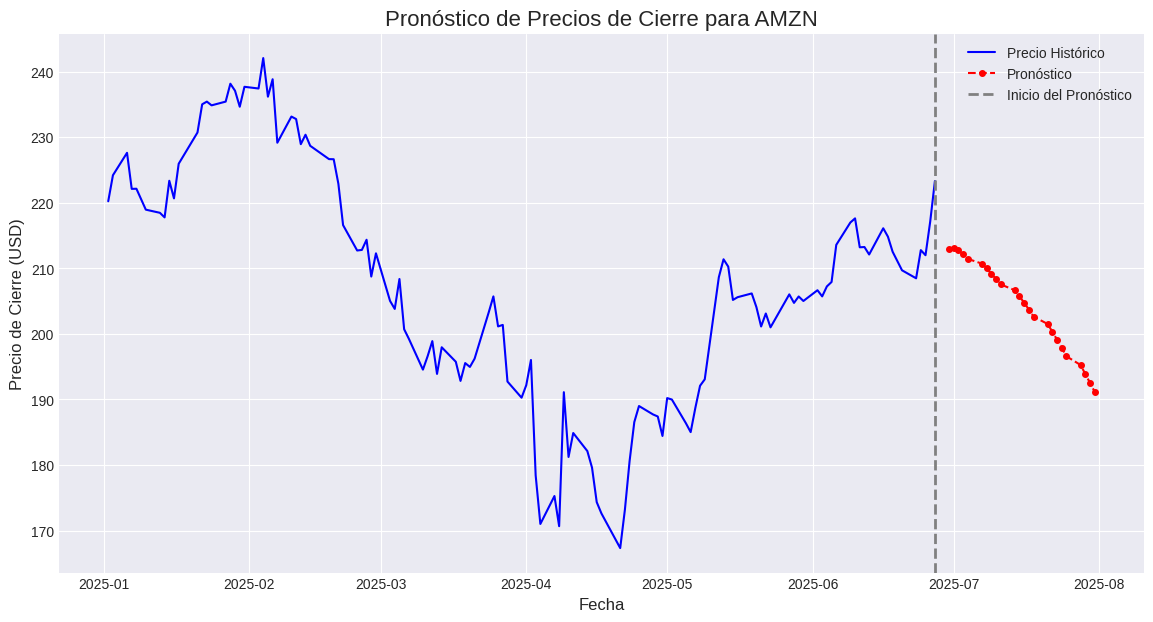

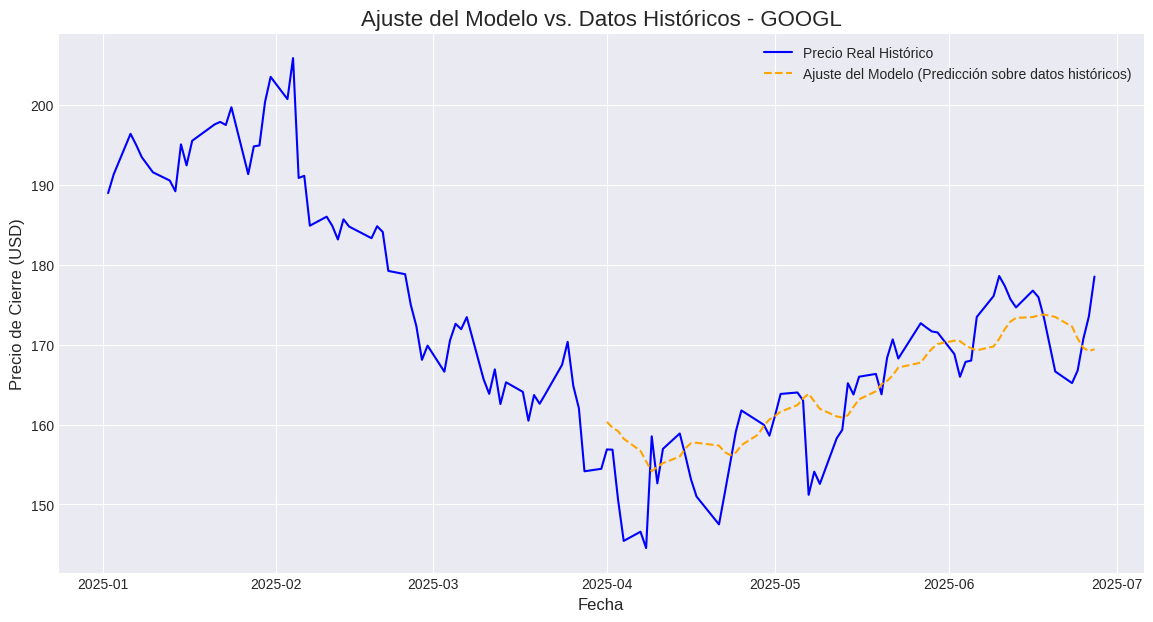

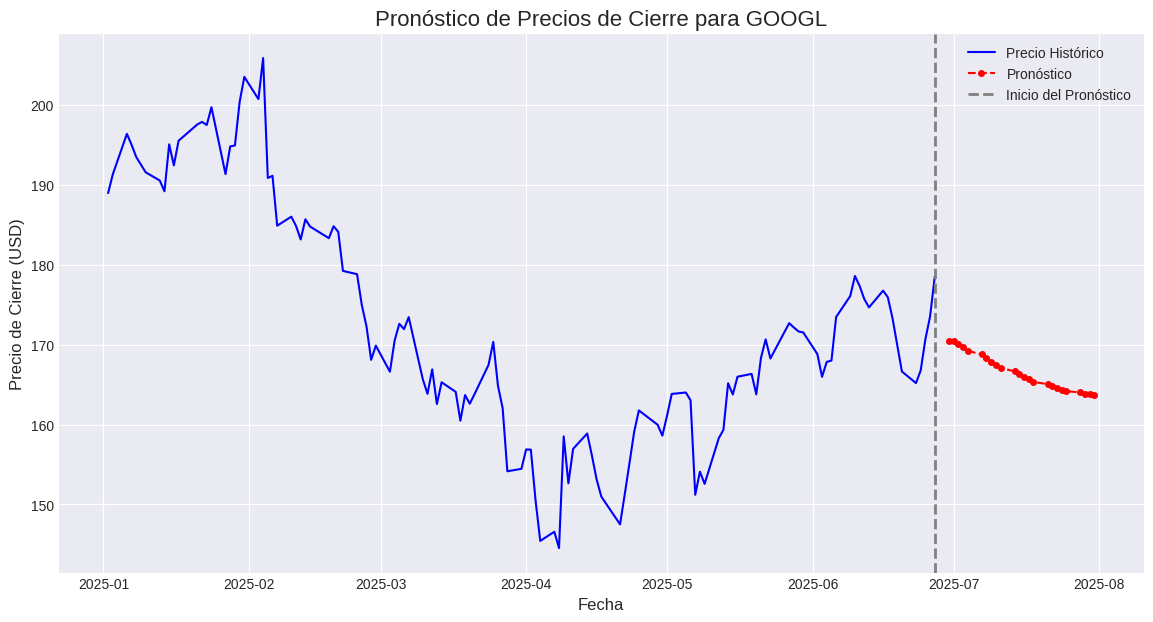

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
import os

# --- Función para graficar los resultados ---
def plot_forecast_results(original_data, model_fit_predictions, future_forecast_df, look_back, stock_ticker):
    """
    Crea y muestra dos gráficas: el ajuste del modelo y el pronóstico a futuro.

    :param original_data: DataFrame original con los precios históricos.
    :param model_fit_predictions: Predicciones del modelo sobre los datos de entrenamiento.
    :param future_forecast_df: DataFrame con las fechas y precios pronosticados a futuro.
    :param look_back: Ventana de tiempo usada para entrenar.
    :param stock_ticker: Símbolo de la acción (e.g., 'AMZN') para los títulos de las gráficas.
    """
    plt.style.use('seaborn-v0_8-darkgrid')

    # --- Gráfica 1: Ajuste del Modelo vs. Datos Históricos ---
    plt.figure(figsize=(14, 7))
    plt.plot(original_data.index, original_data.values, color='blue', label='Precio Real Histórico')

    # Alinear las predicciones del ajuste con las fechas correctas
    fit_dates = original_data.index[look_back:]
    plt.plot(fit_dates, model_fit_predictions, color='orange', linestyle='--', label='Ajuste del Modelo (Predicción sobre datos históricos)')

    plt.title(f'Ajuste del Modelo vs. Datos Históricos - {stock_ticker}', fontsize=16)
    plt.xlabel('Fecha', fontsize=12)
    plt.ylabel('Precio de Cierre (USD)', fontsize=12)
    plt.legend()
    plt.grid(True)

    # --- Gráfica 2: Pronóstico de Precios a Futuro ---
    plt.figure(figsize=(14, 7))
    # Graficar datos históricos
    plt.plot(original_data.index, original_data.values, color='blue', label='Precio Histórico')

    # Graficar el pronóstico
    plt.plot(future_forecast_df.index, future_forecast_df[f'{stock_ticker}_Forecast'], color='red', linestyle='--', marker='o', markersize=4, label='Pronóstico')

    plt.title(f'Pronóstico de Precios de Cierre para {stock_ticker}', fontsize=16)
    plt.xlabel('Fecha', fontsize=12)
    plt.ylabel('Precio de Cierre (USD)', fontsize=12)
    # Colocar una línea vertical para separar lo histórico del pronóstico
    last_date = original_data.index[-1]
    plt.axvline(x=last_date, color='gray', linestyle='--', linewidth=2, label='Inicio del Pronóstico')
    plt.legend()
    plt.grid(True)


# --- 1. Carga de Datos desde el archivo CSV ---
file_name = 'precios_cierre_2025_google_amazon.csv'

if not os.path.exists(file_name):
    print(f"Error: El archivo '{file_name}' no se encontró.")
else:
    df = pd.read_csv(file_name)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

    def create_sequences(data, look_back=1):
        X, y = [], []
        for i in range(len(data) - look_back):
            X.append(data[i:(i + look_back), 0])
            y.append(data[i + look_back, 0])
        return np.array(X), np.array(y)

    def train_and_forecast(data, look_back, forecast_days):
        scaler = MinMaxScaler(feature_range=(0, 1))
        scaled_data = scaler.fit_transform(data.values.reshape(-1, 1))

        X_train, y_train = create_sequences(scaled_data, look_back)
        X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

        model = Sequential([
            LSTM(50, return_sequences=True, input_shape=(look_back, 1)), Dropout(0.2),
            LSTM(50, return_sequences=False), Dropout(0.2),
            Dense(25), Dense(1)
        ])
        model.compile(optimizer='adam', loss='mean_squared_error')
        model.fit(X_train, y_train, batch_size=1, epochs=20, verbose=0)

        # Generar predicciones sobre los datos de entrenamiento para la gráfica de ajuste
        model_fit_predictions_scaled = model.predict(X_train, verbose=0)
        model_fit_predictions = scaler.inverse_transform(model_fit_predictions_scaled)

        # Generar pronósticos a futuro
        last_sequence = scaled_data[-look_back:]
        current_batch = last_sequence.reshape((1, look_back, 1))
        future_predictions_scaled = []
        for i in range(forecast_days):
            current_pred_scaled = model.predict(current_batch, verbose=0)[0]
            future_predictions_scaled.append(current_pred_scaled)
            current_batch = np.append(current_batch[:, 1:, :], [[current_pred_scaled]], axis=1)

        future_forecast = scaler.inverse_transform(future_predictions_scaled)

        return future_forecast.flatten(), model_fit_predictions.flatten()

    # --- Ejecución del Pronóstico ---
    LOOK_BACK = 60
    LAST_DATE = df.index[-1]
    forecast_dates = pd.bdate_range(start=LAST_DATE + pd.Timedelta(days=1), end='2025-07-31')
    FORECAST_DAYS = len(forecast_dates)

    print("Iniciando el pronóstico...")
    print("-" * 50)

    # Pronóstico para Amazon (AMZN)
    print("Entrenando modelo y pronosticando para Amazon (AMZN)...")
    amzn_data = df[['AMZN_Close']]
    amzn_forecast, amzn_model_fit = train_and_forecast(amzn_data, LOOK_BACK, FORECAST_DAYS)

    # Pronóstico para Google (GOOGL)
    print("Entrenando modelo y pronosticando para Google (GOOGL)...")
    googl_data = df[['GOOGL_Close']]
    googl_forecast, googl_model_fit = train_and_forecast(googl_data, LOOK_BACK, FORECAST_DAYS)
    print("Pronósticos completados.")
    print("-" * 50)

    # --- Preparación de datos para la tabla y las gráficas ---
    forecast_df = pd.DataFrame({
        'Date': forecast_dates,
        'AMZN_Forecast': amzn_forecast,
        'GOOGL_Forecast': googl_forecast
    }).set_index('Date')

    # --- Graficar resultados ---
    print("Generando gráficas...")
    plot_forecast_results(amzn_data, amzn_model_fit, forecast_df[['AMZN_Forecast']], LOOK_BACK, 'AMZN')
    plot_forecast_results(googl_data, googl_model_fit, forecast_df[['GOOGL_Forecast']], LOOK_BACK, 'GOOGL')

    # --- Presentación de la tabla de resultados ---
    # Crear una copia formateada para la visualización en tabla
    formatted_forecast_df = forecast_df.copy()
    formatted_forecast_df['AMZN_Forecast'] = formatted_forecast_df['AMZN_Forecast'].map('${:,.2f}'.format)
    formatted_forecast_df['GOOGL_Forecast'] = formatted_forecast_df['GOOGL_Forecast'].map('${:,.2f}'.format)

    print("\n*** PRONÓSTICO DE PRECIOS DE CIERRE (JUNIO - JULIO 2025) ***\n")
    print(formatted_forecast_df)

    # Mostrar todas las gráficas generadas
    print("\nCerrar las ventanas de las gráficas para finalizar el script.")
    plt.show()

Iniciando el pronóstico...

Procesando Amazon (AMZN)...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



--- MÉTRICAS DE ERROR PARA AMZN (Ajuste sobre datos históricos) ---
Mean Absolute Error (MAE):    $6.9582
Root Mean Squared Error (RMSE): $8.7465
R-squared (R²):               0.6444
------------------------------------------------------------
Interpretación:
  - MAE: En promedio, las predicciones del modelo se desviaron $6.96 del precio real.
  - R²: El modelo explica el 64.4% de la variabilidad en los precios históricos.
------------------------------------------------------------

Procesando Google (GOOGL)...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



--- MÉTRICAS DE ERROR PARA GOOGL (Ajuste sobre datos históricos) ---
Mean Absolute Error (MAE):    $3.9260
Root Mean Squared Error (RMSE): $4.9685
R-squared (R²):               0.6968
------------------------------------------------------------
Interpretación:
  - MAE: En promedio, las predicciones del modelo se desviaron $3.93 del precio real.
  - R²: El modelo explica el 69.7% de la variabilidad en los precios históricos.
------------------------------------------------------------

Generando gráficas...

*** PRONÓSTICO DE PRECIOS DE CIERRE (JUNIO - JULIO 2025) ***

           AMZN_Forecast GOOGL_Forecast
Date                                   
2025-06-30       $205.43        $166.94
2025-07-01       $204.85        $166.41
2025-07-02       $203.74        $165.51
2025-07-03       $202.43        $164.48
2025-07-04       $201.08        $163.40
2025-07-07       $199.76        $162.34
2025-07-08       $198.49        $161.28
2025-07-09       $197.31        $160.26
2025-07-10       $196.21

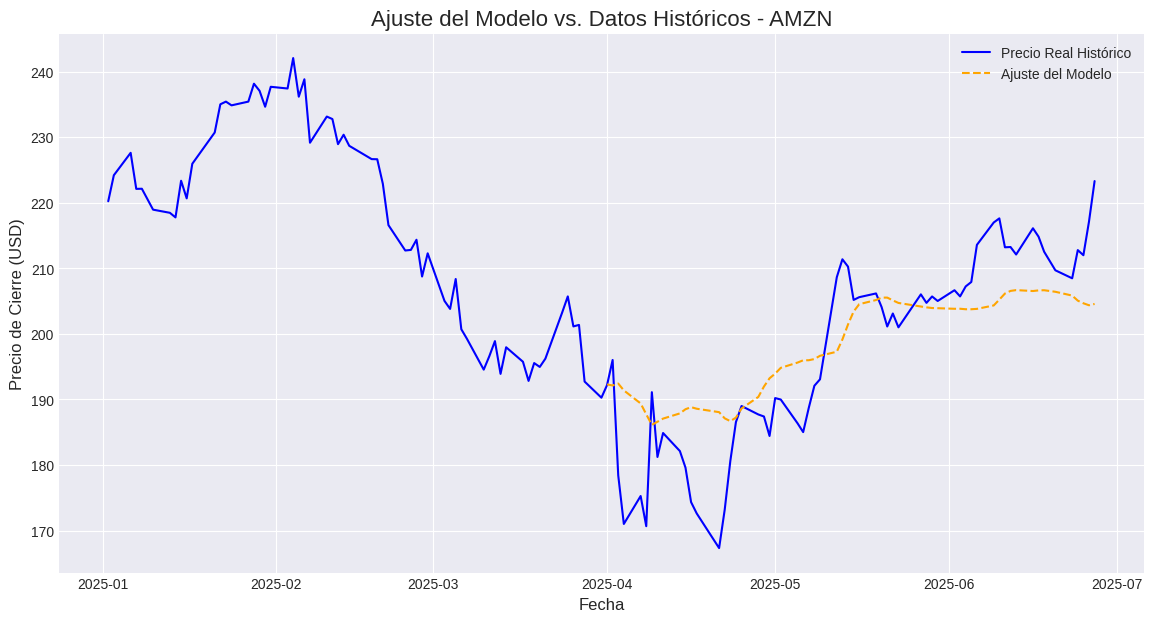

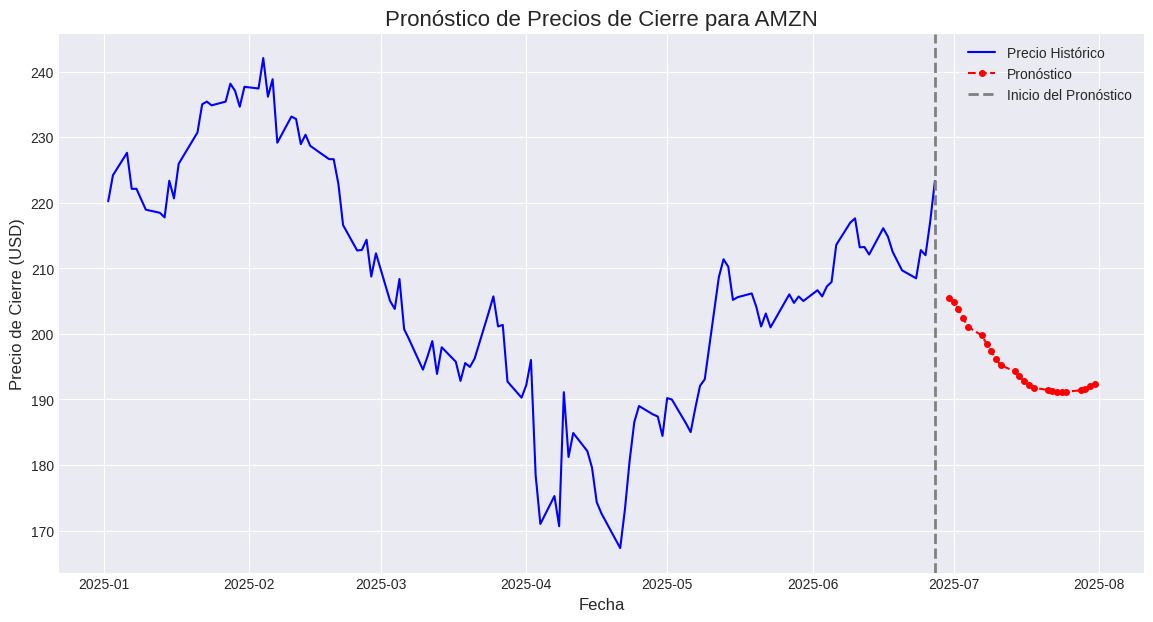

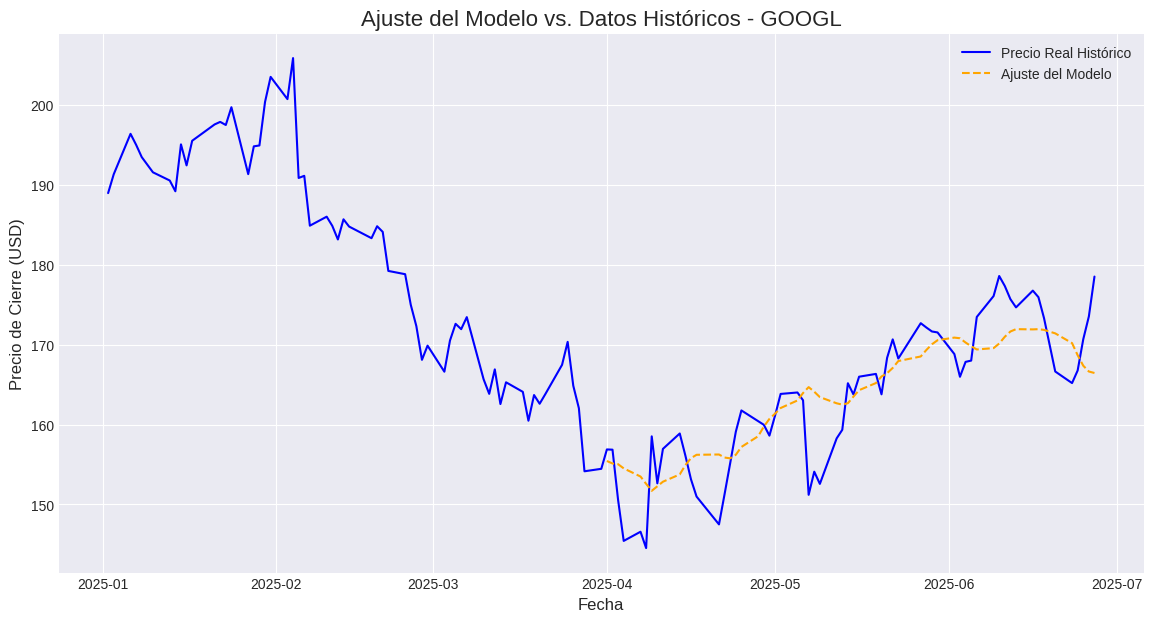

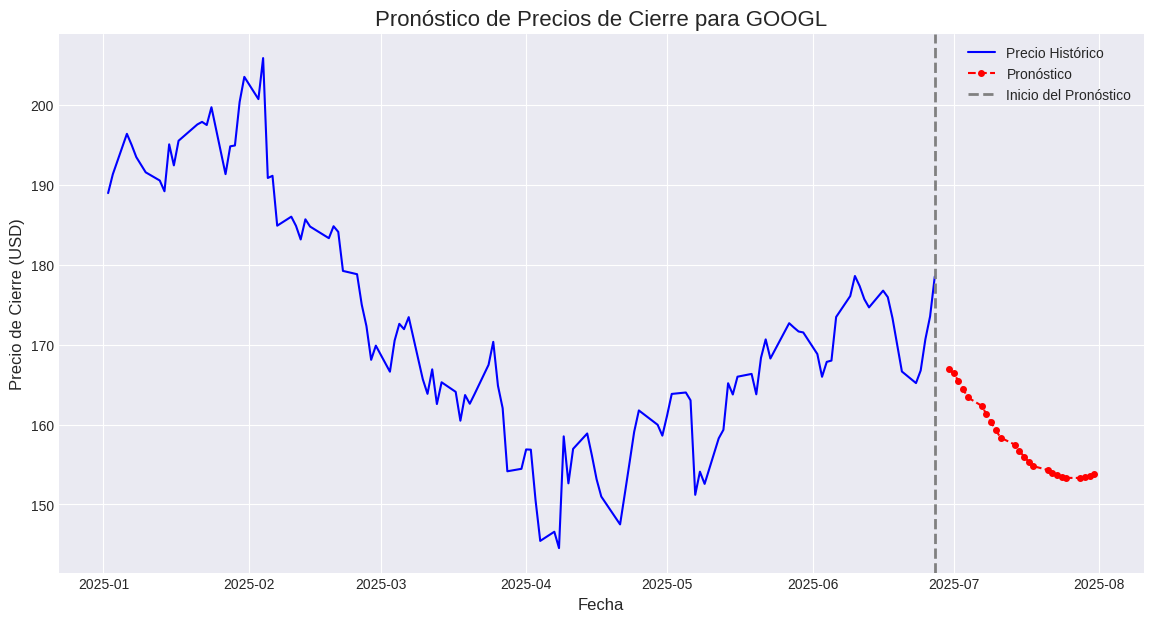

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
import os

# --- Función para calcular y mostrar métricas de error ---
def calculate_and_print_metrics(y_true, y_pred, stock_ticker):
    """
    Calcula y muestra las métricas de rendimiento del modelo.

    :param y_true: Valores reales (históricos).
    :param y_pred: Valores predichos por el modelo sobre el mismo período.
    :param stock_ticker: Símbolo de la acción para la visualización.
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n--- MÉTRICAS DE ERROR PARA {stock_ticker} (Ajuste sobre datos históricos) ---")
    print(f"Mean Absolute Error (MAE):    ${mae:.4f}")
    print(f"Root Mean Squared Error (RMSE): ${rmse:.4f}")
    print(f"R-squared (R²):               {r2:.4f}")
    print("-" * 60)
    print("Interpretación:")
    print(f"  - MAE: En promedio, las predicciones del modelo se desviaron ${mae:.2f} del precio real.")
    print(f"  - R²: El modelo explica el {r2:.1%} de la variabilidad en los precios históricos.")
    print("-" * 60)

# --- Función para graficar los resultados ---
def plot_forecast_results(original_data, model_fit_predictions, future_forecast_df, look_back, stock_ticker):
    plt.style.use('seaborn-v0_8-darkgrid')

    # Gráfica 1: Ajuste del Modelo vs. Datos Históricos
    plt.figure(figsize=(14, 7))
    plt.plot(original_data.index, original_data.values, color='blue', label='Precio Real Histórico')
    fit_dates = original_data.index[look_back:]
    plt.plot(fit_dates, model_fit_predictions, color='orange', linestyle='--', label='Ajuste del Modelo')
    plt.title(f'Ajuste del Modelo vs. Datos Históricos - {stock_ticker}', fontsize=16)
    plt.xlabel('Fecha', fontsize=12); plt.ylabel('Precio de Cierre (USD)', fontsize=12)
    plt.legend(); plt.grid(True)

    # Gráfica 2: Pronóstico de Precios a Futuro
    plt.figure(figsize=(14, 7))
    plt.plot(original_data.index, original_data.values, color='blue', label='Precio Histórico')
    plt.plot(future_forecast_df.index, future_forecast_df[f'{stock_ticker}_Forecast'], color='red', linestyle='--', marker='o', markersize=4, label='Pronóstico')
    plt.title(f'Pronóstico de Precios de Cierre para {stock_ticker}', fontsize=16)
    plt.xlabel('Fecha', fontsize=12); plt.ylabel('Precio de Cierre (USD)', fontsize=12)
    last_date = original_data.index[-1]
    plt.axvline(x=last_date, color='gray', linestyle='--', linewidth=2, label='Inicio del Pronóstico')
    plt.legend(); plt.grid(True)

# --- 1. Carga de Datos desde el archivo CSV ---
file_name = 'precios_cierre_2025_google_amazon.csv'

if not os.path.exists(file_name):
    print(f"Error: El archivo '{file_name}' no se encontró.")
else:
    df = pd.read_csv(file_name)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

    def create_sequences(data, look_back=1):
        X, y = [], []
        for i in range(len(data) - look_back):
            X.append(data[i:(i + look_back), 0])
            y.append(data[i + look_back, 0])
        return np.array(X), np.array(y)

    def train_and_forecast(data, look_back, forecast_days):
        scaler = MinMaxScaler(feature_range=(0, 1))
        scaled_data = scaler.fit_transform(data.values.reshape(-1, 1))
        X_train, y_train_scaled = create_sequences(scaled_data, look_back)
        X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

        model = Sequential([
            LSTM(50, return_sequences=True, input_shape=(look_back, 1)), Dropout(0.2),
            LSTM(50, return_sequences=False), Dropout(0.2),
            Dense(25), Dense(1)
        ])
        model.compile(optimizer='adam', loss='mean_squared_error')
        model.fit(X_train, y_train_scaled, batch_size=1, epochs=20, verbose=0)

        # Predicciones sobre datos de entrenamiento para calcular métricas
        model_fit_predictions_scaled = model.predict(X_train, verbose=0)
        model_fit_predictions = scaler.inverse_transform(model_fit_predictions_scaled)

        # Pronósticos a futuro
        last_sequence = scaled_data[-look_back:]
        current_batch = last_sequence.reshape((1, look_back, 1))
        future_predictions_scaled = []
        for i in range(forecast_days):
            current_pred_scaled = model.predict(current_batch, verbose=0)[0]
            future_predictions_scaled.append(current_pred_scaled)
            current_batch = np.append(current_batch[:, 1:, :], [[current_pred_scaled]], axis=1)
        future_forecast = scaler.inverse_transform(future_predictions_scaled)

        return future_forecast.flatten(), model_fit_predictions.flatten()

    # --- Ejecución del Pronóstico ---
    LOOK_BACK = 60
    LAST_DATE = df.index[-1]
    forecast_dates = pd.bdate_range(start=LAST_DATE + pd.Timedelta(days=1), end='2025-07-31')
    FORECAST_DAYS = len(forecast_dates)

    print("Iniciando el pronóstico...")

    # --- AMAZON (AMZN) ---
    print("\nProcesando Amazon (AMZN)...")
    amzn_data = df[['AMZN_Close']]
    amzn_forecast, amzn_model_fit = train_and_forecast(amzn_data, LOOK_BACK, FORECAST_DAYS)
    # Calcular métricas para AMZN
    amzn_y_true = amzn_data.values[LOOK_BACK:]
    calculate_and_print_metrics(amzn_y_true, amzn_model_fit, 'AMZN')

    # --- GOOGLE (GOOGL) ---
    print("\nProcesando Google (GOOGL)...")
    googl_data = df[['GOOGL_Close']]
    googl_forecast, googl_model_fit = train_and_forecast(googl_data, LOOK_BACK, FORECAST_DAYS)
    # Calcular métricas para GOOGL
    googl_y_true = googl_data.values[LOOK_BACK:]
    calculate_and_print_metrics(googl_y_true, googl_model_fit, 'GOOGL')

    # --- Preparación de datos para la tabla y las gráficas ---
    forecast_df = pd.DataFrame({
        'Date': forecast_dates,
        'AMZN_Forecast': amzn_forecast,
        'GOOGL_Forecast': googl_forecast
    }).set_index('Date')

    print("\nGenerando gráficas...")
    plot_forecast_results(amzn_data, amzn_model_fit, forecast_df[['AMZN_Forecast']], LOOK_BACK, 'AMZN')
    plot_forecast_results(googl_data, googl_model_fit, forecast_df[['GOOGL_Forecast']], LOOK_BACK, 'GOOGL')

    formatted_forecast_df = forecast_df.copy()
    formatted_forecast_df['AMZN_Forecast'] = formatted_forecast_df['AMZN_Forecast'].map('${:,.2f}'.format)
    formatted_forecast_df['GOOGL_Forecast'] = formatted_forecast_df['GOOGL_Forecast'].map('${:,.2f}'.format)

    print("\n*** PRONÓSTICO DE PRECIOS DE CIERRE (JUNIO - JULIO 2025) ***\n")
    print(formatted_forecast_df)

    print("\nCerrar las ventanas de las gráficas para finalizar el script.")
    plt.show()